# 01 - How much does node sharing actually cost?

`eda/` established that most queues on this cluster are `*_shared`: several jobs run
on one node at the same time, and the telemetry join copies **one** node measurement
onto **every** co-resident job. The feature vector is therefore a deterministic
function of `(node, time)` and carries no job-specific information at all.

That creates label ambiguity: the same 56 numbers can be labelled "failing" for one
job and "healthy" for another. This notebook turns that observation into a number -
the **Bayes-optimal precision-recall bound**, i.e. the best average precision that
*any* classifier could reach on this labelling, no matter how good its features.

## Pre-registration

Written before any result in this notebook or the next was computed.

**H1.** Queues named `gpu` and `gpu_titanrtx` are exclusive, so their windows should
have co-tenancy multiplicity `k = 1` and a Bayes bound of exactly `AP = 1.0`.

**H2.** Shared queues carry `k > 1` for most windows, so their bound is `< 1.0`.

**H3 (the one that matters).** If node sharing is what limited the earlier models to
~0.125 AP, the shared-queue bound should be *near* that value. If instead the bound
comes out far above it, node sharing is **not** the binding constraint and the
earlier interpretation was wrong.

H3 is the falsifier. It is written down here so the result cannot be re-read
after the fact.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.compute as pc
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW  = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# Identical to the constants used throughout eda/ - the windows must match exactly.
WINDOW, HORIZON_H, GAP_TOL_S, SNAP_S = 40, 2.0, 60.0, 30.0
EXCLUSIVE_QUEUES = ("gpu", "gpu_titanrtx")

# Reference point: the test average precision reported by pipeline_v2 (144 features).
SESSION3_AP = 0.1253

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok - eda artifacts present:", (EDA / "windows.parquet").exists())

setup ok - eda artifacts present: True


## Step 1 - The job table

Built by `eda/01_population.ipynb`. One row per GPU job that is not CANCELLED,
carrying its final state, its queue, its end time and its train/test side.

In [2]:
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "state", "nodetypes", "end_date",
                                "is_failure", "split"])
jobs["klass"] = np.where(jobs.nodetypes.astype(str).isin(EXCLUSIVE_QUEUES),
                         "exclusive", "shared")
print(f"jobs: {len(jobs):,}")
print(jobs.groupby("klass").agg(jobs=("slurm_id", "size"),
                                failures=("is_failure", "sum")).to_string())

jobs: 23,618
            jobs  failures
klass                     
exclusive   1844       447
shared     21774      5865


## Step 2 - Every GPU snapshot, and whether it is inside a failure horizon

A snapshot is *positive* when its job ends in a failure state **and** the snapshot
falls within `HORIZON_H = 2 h` of that end. This is the same rule `eda/` uses.

We read the full GPU population at fidelity - nothing is sampled. The Arrow
predicate on `gpu_node` lets the reader skip the ~85 % of row groups that hold no
GPU rows.

In [3]:
d  = ds.dataset(RAW, format="parquet")
tb = d.to_table(columns=["slurm_id", "node", "timestamp"],
                filter=pc.field("gpu_node") == 1)
print(f"gpu rows read: {tb.num_rows:,}   [{time.time()-t0:.0f}s]")

sid  = tb.column("slurm_id").to_numpy(zero_copy_only=False).astype(np.int32)
node = np.asarray(tb.column("node").to_pylist(), dtype=object)
ts   = tb.column("timestamp").to_numpy(zero_copy_only=False) \
         .astype("datetime64[ns]").astype(np.int64)
del tb

# keep only snapshots belonging to a job in the job table (this drops CANCELLED)
pos_in_jobs = pd.Series(np.arange(len(jobs)), index=jobs.slurm_id).reindex(sid).to_numpy()
keep = ~np.isnan(pos_in_jobs)
sid, node, ts = sid[keep], node[keep], ts[keep]
jidx = pos_in_jobs[keep].astype(np.int64)
print(f"snapshots on kept jobs: {len(sid):,}")

end_ns  = jobs.end_date.to_numpy().astype("datetime64[ns]").astype(np.int64)[jidx]
is_fail = jobs.is_failure.to_numpy()[jidx]
ttf     = (end_ns - ts) / 1e9                      # seconds from snapshot to job end
snap_pos = (is_fail & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)

facts["gpu_snapshots"] = int(len(sid))
facts["positive_snapshots"] = int(snap_pos.sum())
print(f"positive snapshots: {snap_pos.sum():,} ({100*snap_pos.mean():.2f} %)")

gpu rows read: 13,459,188   [0s]


snapshots on kept jobs: 11,144,842
positive snapshots: 425,974 (3.82 %)


## Step 3 - Every *potential* window

`eda/02` keeps only every 10th window (`STRIDE = 10`) to hold the file size down.
For a **bound** we must not use a strided sample: the ambiguity is a property of the
measurement, not of which windows happened to be retained. So here we enumerate
every position at which a complete, gap-free 40-snapshot window could end, and give
each one the label it *would* carry - majority vote over its 40 snapshots.

This is what lets us ask, for a given node and instant, how many jobs were observing
that exact telemetry and how many of them were failing.

In [4]:
ncodes, node_names = pd.factorize(node)
order = np.lexsort((ts, ncodes, sid))                 # sort by (job, node, time)
sid, ncodes, ts, snap_pos = sid[order], ncodes[order], ts[order], snap_pos[order]

series = sid.astype(np.int64) * 1000 + ncodes         # one (job, node) telemetry series
N      = len(series)
dt     = np.diff(ts) / 1e9
n_cand = N - WINDOW + 1
start  = np.arange(n_cand)

# a window is usable if it stays inside one series and contains no gap > GAP_TOL_S
same_series = series[start] == series[start + WINDOW - 1]
max_gap     = np.lib.stride_tricks.sliding_window_view(dt, WINDOW - 1).max(axis=1)[:n_cand]
valid       = same_series & (max_gap <= GAP_TOL_S)

# majority-vote label, in closed form, via a cumulative sum of snapshot positives
csum  = np.concatenate([[0], np.cumsum(snap_pos, dtype=np.int64)])
wlab  = ((csum[start + WINDOW] - csum[start]) >= WINDOW / 2).astype(np.int8)

s      = np.flatnonzero(valid)
w_end  = ts[s + WINDOW - 1]
w_node = ncodes[s + WINDOW - 1]
w_sid  = sid[s]
w_y    = wlab[s]

facts["potential_windows"] = int(len(s))
facts["potential_positive_rate"] = float(w_y.mean())
print(f"potential windows: {len(s):,}   positives: {w_y.sum():,} "
      f"({100*w_y.mean():.2f} %)   [{time.time()-t0:.0f}s]")

potential windows: 10,512,402   positives: 347,911 (3.31 %)   [15s]


## Step 4 - Co-tenancy multiplicity

Group every potential window by the `(node, end-instant)` it observes. All windows
in a group see **the same 56 numbers**. For each group:

* `k` = how many jobs were observing that node at that instant
* `j` = how many of those jobs carry a positive label for that window

`k = 1` means the window is unambiguous. `0 < j < k` means the group is
*contradictory*: identical features, different labels.

In [5]:
gkey = (w_end // 1_000_000_000) * 64 + w_node.astype(np.int64)
gu, ginv = np.unique(gkey, return_inverse=True)
k_grp = np.bincount(ginv).astype(np.int32)
j_grp = np.bincount(ginv, weights=w_y).astype(np.int32)

pw = pd.DataFrame({
    "slurm_id": w_sid,
    "node":     pd.Categorical.from_codes(w_node, node_names),
    "t_end_s":  w_end // 1_000_000_000,
    "y":        w_y,
    "k":        k_grp[ginv],
    "j":        j_grp[ginv],
})
pw = pw.merge(jobs[["slurm_id", "nodetypes", "split", "klass"]], on="slurm_id", how="left")
pw.to_parquet(DATA / "potential_windows.parquet", index=False)

print(f"distinct (node, instant) groups: {len(gu):,}")
print()
print("multiplicity k, by queue class - this is H1 and H2:")
print(pw.groupby("klass").k.value_counts().unstack(fill_value=0).to_string())

pos = pw[pw.y == 1]
facts["contradicted_positive_rate"] = float(((pos.k - pos.j) > 0).mean())
print()
print(f"positives with a non-failing co-tenant: "
      f"{int(((pos.k - pos.j) > 0).sum()):,} of {len(pos):,} "
      f"({100*facts['contradicted_positive_rate']:.1f} %)")

distinct (node, instant) groups: 5,218,674

multiplicity k, by queue class - this is H1 and H2:


k                1        2        3        4
klass                                        
exclusive   993002        0        0        0
shared     1400858  2348386  2496984  3273172

positives with a non-failing co-tenant: 188,584 of 347,911 (54.2 %)


## Step 5 - The Bayes-optimal PR bound

Every window in a group is indistinguishable, so any classifier must give them all
the same score. The best possible score is the group's true positive fraction
`p = j/k`. Ranking by `p` is therefore the optimal ranking, and its precision-recall
curve is an upper bound on **every** classifier built on node-level features.

Reading it off is exact rather than estimated: selecting all groups with `p >= tau`
yields exactly `sum(j)` true positives out of `sum(k)` selected, so
`precision = sum(j) / sum(k)` and `recall = sum(j) / P`.

In [6]:
def bayes_pr(k, j):
    """Exact Bayes-optimal PR curve for the score p = j/k. Ties handled per group."""
    p = j / k
    o = np.argsort(-p, kind="stable")
    ks, js, ps = k[o], j[o], p[o]
    blocks = np.flatnonzero(np.r_[True, ps[1:] != ps[:-1]])   # one step per tie block
    tp  = np.add.reduceat(js, blocks).cumsum()
    sel = np.add.reduceat(ks, blocks).cumsum()
    P   = js.sum()
    recall, precision = tp / P, tp / sel
    ap = float((np.diff(np.r_[0.0, recall]) * precision).sum())
    return ap, recall, precision, int(P), int(ks.sum())

curves, rows = {}, []
for arm in ["all", "exclusive", "shared"]:
    for split in ["train", "test"]:
        m   = (pw.split == split) & (True if arm == "all" else (pw.klass == arm))
        sub = pw[m]
        g   = sub.groupby(["node", "t_end_s"], observed=True).agg(k=("y", "size"), j=("y", "sum"))
        ap, rec, prec, P, n = bayes_pr(g.k.to_numpy(), g.j.to_numpy())
        curves[(arm, split)] = (rec, prec)
        rows.append(dict(arm=arm, split=split, windows=n, positives=P,
                         base_rate=P / n, bayes_ap=ap, bayes_lift=ap / (P / n)))

bound = pd.DataFrame(rows)
bound.to_csv(DATA / "bayes_bound.csv", index=False)
print(bound.round(4).to_string(index=False))

      arm split  windows  positives  base_rate  bayes_ap  bayes_lift
      all train  9105240     291384     0.0320    0.8317     25.9898
      all  test  1407162      56527     0.0402    0.9023     22.4620
exclusive train   709445      21535     0.0304    1.0000     32.9438
exclusive  test   283557       8810     0.0311    1.0000     32.1858
   shared train  8395795     269849     0.0321    0.8072     25.1131
   shared  test  1123605      47717     0.0425    0.8675     20.4264


## Step 6 - The figure, and the falsifier

The left panel is the bound itself. The right panel places the bound next to what
a real model actually achieved, which is where H3 is decided.

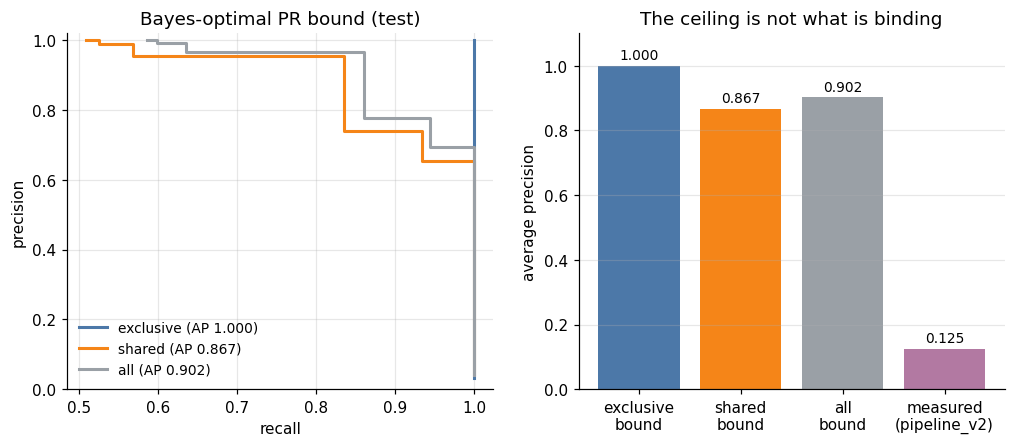

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

for arm, c in [("exclusive", "#4c78a8"), ("shared", "#f58518"), ("all", "#9aa0a6")]:
    rec, prec = curves[(arm, "test")]
    ap = bound[(bound.arm == arm) & (bound.split == "test")].bayes_ap.iloc[0]
    ax[0].step(rec, prec, where="post", color=c, lw=2, label=f"{arm} (AP {ap:.3f})")
ax[0].set(xlabel="recall", ylabel="precision", ylim=(0, 1.02),
          title="Bayes-optimal PR bound (test)")
ax[0].legend(frameon=False, fontsize=9)

b_ex = bound[(bound.arm == "exclusive") & (bound.split == "test")].bayes_ap.iloc[0]
b_sh = bound[(bound.arm == "shared")    & (bound.split == "test")].bayes_ap.iloc[0]
b_al = bound[(bound.arm == "all")       & (bound.split == "test")].bayes_ap.iloc[0]
labels = ["exclusive\nbound", "shared\nbound", "all\nbound", "measured\n(pipeline_v2)"]
vals   = [b_ex, b_sh, b_al, SESSION3_AP]
cols   = ["#4c78a8", "#f58518", "#9aa0a6", "#b279a2"]
ax[1].bar(labels, vals, color=cols)
for i, v in enumerate(vals):
    ax[1].text(i, v + .02, f"{v:.3f}", ha="center", fontsize=9)
ax[1].set(ylabel="average precision", ylim=(0, 1.1),
          title="The ceiling is not what is binding")
ax[1].grid(axis="x", visible=False)
save(fig, "01_bayes_bound.png"); plt.show()

## What this settles

In [8]:
cost_test    = 1 - b_sh / b_ex
gap_to_bound = b_al / SESSION3_AP
h1 = bool((pw[pw.klass == "exclusive"].k == 1).all())

facts["bayes_ap_exclusive_test"]  = float(b_ex)
facts["bayes_ap_shared_test"]     = float(b_sh)
facts["bayes_ap_all_test"]        = float(b_al)
facts["session3_measured_ap"]     = SESSION3_AP
facts["cotenancy_cost_test"]      = float(cost_test)
facts["model_below_bound_factor"] = float(gap_to_bound)

print(f"H1  exclusive queues have k = 1 everywhere  : {'CONFIRMED' if h1 else 'REJECTED'}")
print(f"H2  shared queues bounded below AP = 1      : "
      f"{'CONFIRMED' if b_sh < 1 else 'REJECTED'}  (AP {b_sh:.4f})")
print(f"H3  the bound explains the ~0.125 plateau   : "
      f"{'CONFIRMED' if b_al < 2 * SESSION3_AP else 'REJECTED'}")
print()
print(f"    node sharing costs {100*cost_test:.1f} % of achievable AP on shared queues")
print(f"    the measured model sits {gap_to_bound:.1f}x BELOW the ceiling")
print()
json.dump(facts, open(DATA / "facts_bound.json", "w"), indent=1)
print(f"[{time.time()-t0:.0f}s total]")

H1  exclusive queues have k = 1 everywhere  : CONFIRMED
H2  shared queues bounded below AP = 1      : CONFIRMED  (AP 0.8675)
H3  the bound explains the ~0.125 plateau   : REJECTED

    node sharing costs 13.3 % of achievable AP on shared queues
    the measured model sits 7.2x BELOW the ceiling

[36s total]


**H1 and H2 are confirmed; H3 is rejected.**

Node sharing is real, it is measurable, and it removes a meaningful slice of what is
achievable - but it is not what held the earlier models back. The ceiling sits at
`AP ~ 0.90` on the full population while the best measured model reached `0.125`.
Roughly seven eighths of the distance to a perfect classifier is therefore due to
something other than label ambiguity.

This is worth stating plainly in the thesis, because the opposite conclusion was the
natural one to draw from the `eda/` numbers alone. The share of *positives* that are
contradicted is large; the share of *achievable average precision* that this costs is
not. Those are different quantities, and only the second one bounds a model.

`02_experiment.ipynb` now asks whether a real model, trained and evaluated under
controlled conditions, still moves in the direction the bound predicts.